# Fly around dataset test

In [27]:
%load_ext autoreload
%autoreload 2

import torch 
import random
import numpy as np 
from matplotlib import pyplot as plt
from tqdm import tqdm 
from neuralop.models.fno import FNO
import jax 
import jax.numpy as jnp
from jax import Array
from mpl_toolkits.axes_grid1 import make_axes_locatable
from copy import deepcopy

import sys 
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator")
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators")

from safe_neural_operators.data_collection import load_hjr_solution, load_grid_states, \
    get_dynamics_model_given_disturbance_fn, \
    get_disturbance_function_sincos, get_dynamics_model_given_disturbance_fn
from safe_neural_operators.hjr_dataset import load_full_training_dataset, HJR_SubDataset, HJRDataset
from safe_neural_operators.hjr_full_partial_dataset import HJRFullPartialDataset

sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project/custom_sim/quad2d")
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project/custom_sim")
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project")


from fly_around import get_gridvalue_function_from_model


sys.path.append("/home/jingpei/Documents/arclab/neuraloperator")
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators")
from safe_neural_operators.gt_hjr_solution import GroundTruthHJSolution
# Replaced #from deepreach.utils.comparisons import GroundTruthHJSolution



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# Plotting Functions
import math 

def plot_disturbance_fn_for_hjr(disturbance_fn, img_grid_states): 
    # Plot the disturbance function to be used by HJR solver 
    img_grid_states_shape = img_grid_states.shape
    flat_img_grid_states = img_grid_states.reshape(-1, img_grid_states.shape[-1])  # Flatten to [N, 4]
    disturbance_magnitudes = disturbance_fn(flat_img_grid_states)  # Get disturbance magnitudes
    disturbance_img = disturbance_magnitudes.reshape(img_grid_states_shape[:-1] + (4,))[:, :, 0]  # Reshape to original grid shape

    # Plot the disturbance function image 
    plt.figure()
    plt.imshow(np.rot90(disturbance_img), cmap='viridis', interpolation='nearest')
    plt.title("Disturbance Function for HJR Solver")
    plt.colorbar(label="Disturbance Magnitude")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


def plot_value_functions_comparison_partial(learned_value_function, gt_value_function, xvels_testfn, yvels_testfn, xvels_gtfn, yvels_gtfn, 
                                            xvel_slices_testfn, yvel_slices_testfn, 
                                            xvel_slices_gtfn, yvel_slices_gtfn):
    """
    Function to plot comparison between value functions when the slices of both don't correspond (computed at different resolutions). 
    Args:
        - learned_value_function: The value function computed by the dynamics model (shape: [num_time_steps, grid_size_x, grid_size_y, xvels, yvels])
        - gt_value_function: The ground truth value function (shape: [num_time_steps, grid_size_x, grid_size_y, xvels, yvels])
        - xvels_testfn: The x velocities for the learned value function
        - yvels_testfn: The y velocities for the learned value function
        - xvels_gtfn: The x velocities for the ground truth value function
        - yvels_gtfn: The y velocities for the ground truth value function
        - xvel_slices_testfn: The slices of x velocities for the learned value function
        - yvel_slices_testfn: The slices of y velocities for the learned value function
        - xvel_slices_gtfn: The slices of x velocities for the ground truth value function
        - yvel_slices_gtfn: The slices of y velocities for the ground truth value function
    """
    
    assert(len(xvel_slices_testfn) == len(xvel_slices_gtfn)), "xvel slices for test and gt value functions must be the same length"
    assert(len(yvel_slices_testfn) == len(yvel_slices_gtfn)), "yvel slices for test and gt value functions must be the same length"
    for yvel_slice_num in range(len(yvel_slices_testfn)): 
        # Visualize True Value Function
        # fig, axes = plt.subplots(3, len(xvel_slices_testfn), figsize=(20, 15))
        fig, axes = plt.subplots(4, len(xvel_slices_testfn), figsize=(24, 15))

        for xvel_slice_num in range(len((xvel_slices_testfn))):
            xvel_slice_testfn = xvel_slices_testfn[xvel_slice_num]
            yvel_slice_testfn = yvel_slices_testfn[yvel_slice_num]
            xvel_slice_gtfn = xvel_slices_gtfn[xvel_slice_num]
            yvel_slice_gtfn = yvel_slices_gtfn[yvel_slice_num]
            
            xvel_testfn = xvels_testfn[xvel_slice_testfn]
            yvel_testfn = yvels_testfn[yvel_slice_testfn]
            xvel_gtfn = xvels_gtfn[xvel_slice_gtfn]
            yvel_gtfn = yvels_gtfn[yvel_slice_gtfn]

            # Learned Value Function
            curr_value_function = learned_value_function[:, :, xvel_slice_testfn, yvel_slice_testfn]
            im0 = axes[0, xvel_slice_num].imshow(np.rot90(curr_value_function), cmap='viridis', interpolation='nearest')
            axes[0, xvel_slice_num].contour(np.rot90(curr_value_function), levels=[0], colors='red', linewidths=2)
            axes[0, xvel_slice_num].set_title(f"Learned Value Function\nxvel: {xvel_testfn:.3f}, yvel: {yvel_testfn:.3f}")
            axes[0, xvel_slice_num].set_xlabel("x")
            axes[0, xvel_slice_num].set_ylabel("y")
            divider0 = make_axes_locatable(axes[0, xvel_slice_num])
            cax0 = divider0.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im0, cax=cax0)

            # Ground Truth Value Function
            # gt_value_function = loaded_output[:, :, xvel_slice, yvel_slice]
            gt_value_function_slice = gt_value_function[:, :, xvel_slice_gtfn, yvel_slice_gtfn]
            im1 = axes[1, xvel_slice_num].imshow(np.rot90(gt_value_function_slice), cmap='viridis', interpolation='nearest')
            axes[1, xvel_slice_num].contour(np.rot90(gt_value_function_slice), levels=[0], colors='red', linewidths=2)
            axes[1, xvel_slice_num].set_title(f"GT Value Function\nxvel: {xvel_gtfn:.3f}, yvel: {yvel_gtfn:.3f}")
            axes[1, xvel_slice_num].set_xlabel("x")
            axes[1, xvel_slice_num].set_ylabel("y")
            divider1 = make_axes_locatable(axes[1, xvel_slice_num])
            cax1 = divider1.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im1, cax=cax1)

            # Difference
            difference = curr_value_function - gt_value_function_slice
            im2 = axes[2, xvel_slice_num].imshow(np.rot90(difference), cmap='coolwarm', interpolation='nearest')
            axes[2, xvel_slice_num].contour(np.rot90(difference), levels=[0], colors='red', linewidths=2)
            axes[2, xvel_slice_num].set_title(f"Difference\nxvel: {xvel_testfn:.3f}, yvel: {yvel_testfn:.3f}")
            axes[2, xvel_slice_num].set_xlabel("x")
            axes[2, xvel_slice_num].set_ylabel("y")
            divider2 = make_axes_locatable(axes[2, xvel_slice_num])
            cax2 = divider2.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im2, cax=cax2)

            # Union of safe sets difference
            curr_value_function = np.array(curr_value_function)
            gt_value_function_slice = np.array(gt_value_function_slice)
            above_zero_curr = np.where(curr_value_function > 0, 1, 0)
            above_zero_gt = np.where(gt_value_function_slice > 0, 1, 0)
            all_above_zero_indices = np.where(above_zero_curr + above_zero_gt > 0, 1, 0)
            above_zero_difference = np.where(all_above_zero_indices == 1, difference, math.nan)
            im3 = axes[3, xvel_slice_num].imshow(np.rot90(above_zero_difference), cmap='coolwarm', interpolation='nearest')
            axes[3, xvel_slice_num].contour(np.rot90(above_zero_difference), levels=[0], colors='red', linewidths=2)
            axes[3, xvel_slice_num].set_title(f"Difference in Union of Safe Sets\nxvel: {xvel_testfn:.3f}, yvel: {yvel_testfn:.3f}")
            axes[3, xvel_slice_num].set_xlabel("x")
            axes[3, xvel_slice_num].set_ylabel("y")
            divider3 = make_axes_locatable(axes[3, xvel_slice_num])
            cax3 = divider3.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im3, cax=cax3)

        plt.tight_layout()
        plt.show()

def find_corresponding_indices(xvels, partial_xvels, tolerance=1e-5):
    """
    Finds the indices where the values of two lists correspond within a given tolerance.

    Args:
        xvels (list or numpy.ndarray): The first list of values.
        partial_xvels (list or numpy.ndarray): The second list of values.
        tolerance (float): The tolerance within which values are considered corresponding.

    Returns:
        list: A list of tuples where each tuple contains the index from xvels and the corresponding index from partial_xvels.
    """
    corresponding_indices = []
    for i, xvel in enumerate(xvels):
        for j, partial_xvel in enumerate(partial_xvels):
            if abs(xvel - partial_xvel) <= tolerance:
                corresponding_indices.append((i, j))
    return corresponding_indices



def plot_value_functions_comparison(learned_value_function, gt_value_function, xvels, yvels, xvel_slices = [20, 15, 10, 5, 0], yvel_slices=[20]):
    for yvel_slice in yvel_slices: 
        # Visualize True Value Function
        # fig, axes = plt.subplots(3, len(xvel_slices), figsize=(20, 15))
        fig, axes = plt.subplots(4, len(xvel_slices), figsize=(24, 15))

        for i, xvel_slice in enumerate(xvel_slices):
            xvel = xvels[xvel_slice]
            yvel = yvels[yvel_slice]

            # Learned Value Function
            curr_value_function = learned_value_function[:, :, xvel_slice, yvel_slice]
            im0 = axes[0, i].imshow(np.rot90(curr_value_function), cmap='viridis', interpolation='nearest')
            axes[0, i].contour(np.rot90(curr_value_function), levels=[0], colors='red', linewidths=2)
            axes[0, i].set_title(f"Learned Value Function\nxvel: {xvel}, yvel: {yvel}")
            axes[0, i].set_xlabel("x")
            axes[0, i].set_ylabel("y")
            divider0 = make_axes_locatable(axes[0, i])
            cax0 = divider0.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im0, cax=cax0)

            # Ground Truth Value Function
            # gt_value_function = loaded_output[:, :, xvel_slice, yvel_slice]
            gt_value_function_slice = gt_value_function[:, :, xvel_slice, yvel_slice]
            im1 = axes[1, i].imshow(np.rot90(gt_value_function_slice), cmap='viridis', interpolation='nearest')
            axes[1, i].contour(np.rot90(gt_value_function_slice), levels=[0], colors='red', linewidths=2)
            axes[1, i].set_title(f"GT Value Function\nxvel: {xvel}, yvel: {yvel}")
            axes[1, i].set_xlabel("x")
            axes[1, i].set_ylabel("y")
            divider1 = make_axes_locatable(axes[1, i])
            cax1 = divider1.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im1, cax=cax1)

            # Difference
            difference = curr_value_function - gt_value_function_slice
            im2 = axes[2, i].imshow(np.rot90(difference), cmap='coolwarm', interpolation='nearest')
            axes[2, i].contour(np.rot90(difference), levels=[0], colors='red', linewidths=2)
            axes[2, i].set_title(f"Difference\nxvel: {xvel}, yvel: {yvel}")
            axes[2, i].set_xlabel("x")
            axes[2, i].set_ylabel("y")
            divider2 = make_axes_locatable(axes[2, i])
            cax2 = divider2.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im2, cax=cax2)

            # Union of safe sets difference
            curr_value_function = np.array(curr_value_function)
            gt_value_function_slice = np.array(gt_value_function_slice)
            above_zero_curr = np.where(curr_value_function > 0, 1, 0)
            above_zero_gt = np.where(gt_value_function_slice > 0, 1, 0)
            all_above_zero_indices = np.where(above_zero_curr + above_zero_gt > 0, 1, 0)
            above_zero_difference = np.where(all_above_zero_indices == 1, difference, math.nan)
            im3 = axes[3, i].imshow(np.rot90(above_zero_difference), cmap='coolwarm', interpolation='nearest')
            axes[3, i].contour(np.rot90(above_zero_difference), levels=[0], colors='red', linewidths=2)
            axes[3, i].set_title(f"Difference in Union of Safe Sets\nxvel: {xvel}, yvel: {yvel}")
            axes[3, i].set_xlabel("x")
            axes[3, i].set_ylabel("y")
            divider3 = make_axes_locatable(axes[3, i])
            cax3 = divider3.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(im3, cax=cax3)

        plt.tight_layout()
        plt.show()

In [29]:
randomize_index = True 

In [30]:
# Load the data 

# load_path = "/media/jingpei/DATA/fno_gp_data"
load_path = "/media/jingpei/DATA/fno_data/fno_gp_data_full_partial_750"
use_full_partial_dataset = True

load_index = np.random.randint(0, 500) if randomize_index else 20

loaded_input, loaded_output = load_hjr_solution(
    load_path=load_path,  
    load_index=load_index
)

if use_full_partial_dataset:
    grid_states = load_grid_states(load_path=load_path, load_index=0, load_prefix="full")
else:
    grid_states = load_grid_states(load_path=load_path, load_index=0)

print("loaded_input shape", loaded_input.shape)
print("loaded_output shape", loaded_output.shape)
print("grid_states shape", grid_states.shape)

loaded_input shape torch.Size([41, 41, 4])
loaded_output shape torch.Size([41, 41, 21, 21])
grid_states shape (41, 41, 41, 41, 4)


In [31]:
# Load the model 
# model_dir = "/media/jingpei/DATA/fno_models/safe_neural-7-20-25_500data_revised"
model_dir = "/media/jingpei/DATA/fno_models/safe_neural-8-13-25_fullpartial_500"
device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = FNO.from_checkpoint(save_folder=model_dir, save_name="model")
model = model.to(device)

In [32]:
# Load the data processor r 
data_root_dir = load_path 
samples_for_train = 100 #400 #500
samples_for_test = 50 
datapoints_per_sample = 1000
batch_size = 256 #32
pre_sample_dataset = True 
encode_output = False 
encode_input = True 
encoding = "channel-wise"
full_ordered_dataset = False

if use_full_partial_dataset:
    percent_train = samples_for_train / (samples_for_train + samples_for_test)
    datapoints_per_partial_sample = 400
    dataset = HJRFullPartialDataset(
            root_dir=data_root_dir, 
            samples_for_dataset=samples_for_train + samples_for_test, 
            percent_test=1-percent_train, 
            datapoints_per_full_sample=datapoints_per_sample, 
            datapoints_per_partial_sample=datapoints_per_partial_sample,

            batch_size=batch_size, 
            pre_sample_dataset=pre_sample_dataset,

            encode_input=encode_input, 
            encode_output=encode_output, 
            encoding=encoding
        )
else: 
    dataset = HJRDataset(root_dir=data_root_dir, 
                        samples_for_train=samples_for_train, 
                        samples_for_test=samples_for_test, 
                        datapoints_per_sample=datapoints_per_sample,

                        batch_size=batch_size, 
                        pre_sample_dataset=pre_sample_dataset, 

                        encode_output=encode_output,
                        encode_input=encode_input,
                        encoding=encoding, 
                        full_ordered_dataset=full_ordered_dataset)

data_processor = dataset.data_processor

100%|██████████| 150/150 [00:08<00:00, 16.82it/s]


Retrieved Full Partial Dataset
Number of full data samples: 48, number of partial data samples: 102
Number of full data samples for training: 32, number of partial data samples for training: 68
Number of full data samples for testing: 16, number of partial data samples for testing: 34


# Rerun from here for new datapoint

In [33]:
from safe_neural_operators.data_collection import get_disturbance_function_flyaround, get_disturbance_function_sincos

In [34]:
# bad seeds: 13 nans,  21 blow up

# seed = 13 #21
# np.random.seed(seed)
# torch.manual_seed(seed)
# random.seed(seed)

min_max_magnitude = 0.25 
max_max_magnitude = 0.75 

min_phase_multiplier = 0.05
max_phase_multiplier = 5 

min_phase_shift = 0
max_phase_shift = np.pi / 2


dt = 0.025
tMin = 0.0
tMax = 3.0

max_magnitude = np.random.uniform(min_max_magnitude, max_max_magnitude)
phase_multiplier = np.random.uniform(min_phase_multiplier, max_phase_multiplier)
# MORE VARIATION FOR DEBUGGING
# phase_multiplier = np.random.uniform(1.85, 2.0)  # Reduced range for more variation
# MORE VARIATION FOR DEBUGGING
phase_shift = np.random.uniform(min_phase_shift, max_phase_shift)
dim = np.random.choice(['x', 'y'])
use_sin = np.random.choice([True, False])

full_disturbance_fn = get_disturbance_function_sincos(max_magnitude=max_magnitude, 
                                                      phase_multiplier=phase_multiplier,
                                                      phase_shift=phase_shift, 
                                                      dim=dim, 
                                                      use_sin=use_sin)


initial_sample_radius = np.random.uniform(0.75, 1.5)
fly_around_timesteps = int(np.random.uniform(1000, 7500))
steps_per_goal = np.random.uniform(50, 150)
sample_freq = 5
xy_range = [[grid_states[:, 0, 0, 0, 0].min(), grid_states[:, 0, 0, 0, 0].max()], 
            [grid_states[0, :, 0, 0, 1].min(), grid_states[0, :, 0, 0, 1].max()]]
xy_grid_states = grid_states[:, :, 0, 0, :]

import jax 
flyaround_disturbance_fn, flyaround_gp_model = get_disturbance_function_flyaround(full_disturbance_fn=full_disturbance_fn, 
                                                    initial_sample_radius=initial_sample_radius, 
                                                    fly_around_timesteps=fly_around_timesteps, 
                                                    steps_per_goal=steps_per_goal,
                                                    sample_freq=sample_freq,
                                                    xy_range=xy_range, 
                                                    xy_grid_states=xy_grid_states, 
                                                    dt=dt,
                                                    tMin=tMin, 
                                                    tMax=tMax, 
                                                    min_disturbance_magnitude=0.0,
                                                    max_disturbance_magnitude=max_max_magnitude, 
                                                    return_gp_model=True,
                                                    reoptimize_gp=False, 
                                                    border_padding=None)#3)

100%|██████████| 5543/5543 [00:04<00:00, 1224.04it/s]


Adding new sample to GP model: (1275, 2) (1275, 1)


In [35]:
print("Using disturbance function with parameters: ")
print(f"max_magnitude: {max_magnitude}, phase_multiplier: {phase_multiplier}, phase_shift: {phase_shift}, dim: {dim}, use_sin: {use_sin} \n")

Using disturbance function with parameters: 
max_magnitude: 0.4709851827745748, phase_multiplier: 0.9331575201670604, phase_shift: 0.39223878715517774, dim: x, use_sin: False 



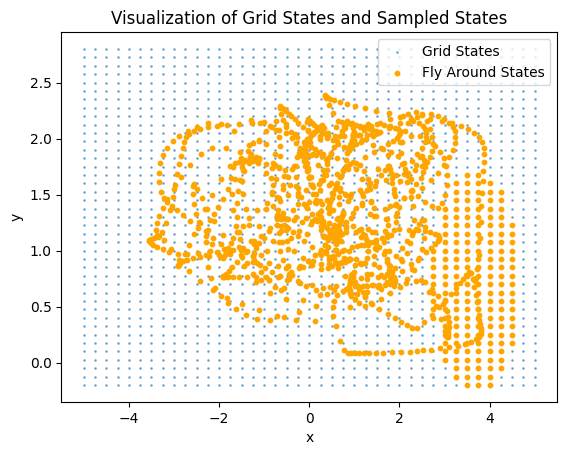

In [36]:
# Visualize the grid of image states and the sampled states within it using the grid states
flattened_img_grid_states = xy_grid_states.reshape(-1, xy_grid_states.shape[-1])  # Flatten to [N, 4]

fig, ax = plt.subplots()
ax.scatter(flattened_img_grid_states[:, 0], flattened_img_grid_states[:, 1], s=1, label="Grid States", alpha=0.5)
ax.scatter(flyaround_gp_model.X[:, 0], flyaround_gp_model.X[:, 1], s=10, color='orange', label="Fly Around States")
ax.set_title("Visualization of Grid States and Sampled States"

)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()


In [37]:
print(flyaround_gp_model.model)


Name : GP regression
Objective : 45285787.37702798
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                   value  |  constraints  |  priors
  rbf.variance             |      0.3715839185014353  |      +ve      |        
  rbf.lengthscale          |      2.7882117632044014  |      +ve      |        
  Gaussian_noise.variance  |  1.8426600205323222e-16  |      +ve      |        


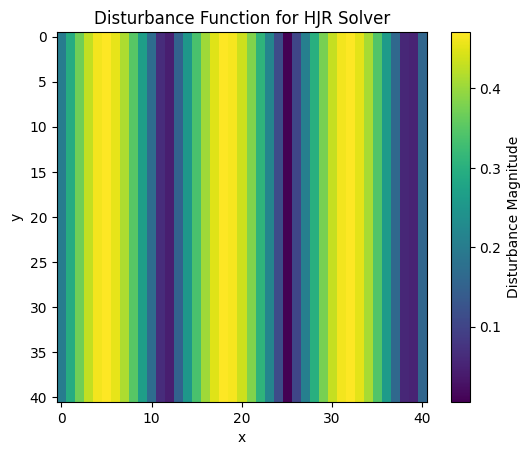

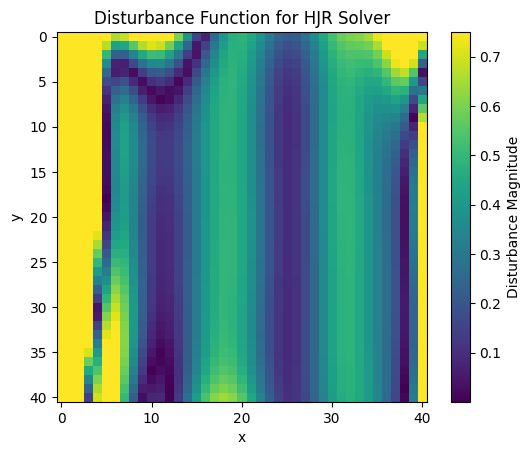

In [38]:
plot_disturbance_fn_for_hjr(full_disturbance_fn, grid_states[:, :, 0, 0, :])
plot_disturbance_fn_for_hjr(flyaround_disturbance_fn, grid_states[:, :, 0, 0, :])

In [39]:

dynamics_model_flyaround_hjr, dynamics_model_flyaround = get_dynamics_model_given_disturbance_fn(
                                                        disturbance_function=flyaround_disturbance_fn,
                                                        tMin=tMin,
                                                        tMax=tMax, 
                                                        ret_system=True
                                                    )


# Solve Ground Truth HJR
num_time_steps = 5
grid_resolution = (41, 41, 21, 21) #(41, 41, 41, 41) 
ground_truth_hj_solution_flyaround = GroundTruthHJSolution(
    hj_dynamics=dynamics_model_flyaround_hjr, 
    solve=True, 
    num_time_steps=num_time_steps, 
    grid_resolution=grid_resolution
)

gt_value_function_flyaround = ground_truth_hj_solution_flyaround.value_functions[-1, :, :, :, :]  # shape grid_resolution - the last time step 

100%|##########|  3.0000/3.0 [00:08<00:00,  2.86s/sim_s]


In [40]:
print("Nan in gt value function: ", np.isnan(gt_value_function_flyaround).any())

Nan in gt value function:  False


In [41]:
# Get Image from GP with proper thresholding for HJR
def gp_model_to_2dinput_image_with_clipping(gp_regression_model, grid_states, vmin, vmax, num_std_away):
    """
    NOTE: this looks certain std away to and clips the image between vmin and vmax - more suitable for HJR and NN inputs

    Get the 2D disturbance input image from the GP model: 
    NOTE: GP model is only trained on [x,y] -> disturbance value: doesn't care about xvel, yvel here
    As a result image is disturbance value over the x,y grid only
    """
    # grid_states: [x, y, xvel, yvel, 4] state: [x,y,xvel,yvel]
    model_input_indices = [0, 1]  # x, y

    # Get states corresponding to image grid 
    image_grid = grid_states[:, :, 0, 0, :][:, :, model_input_indices]  # [x, y, 2]
    flattened_image_grid = image_grid.reshape(-1, image_grid.shape[-1])  # Flatten to [N, 2]

    # Get the corresponding outputs 
    flattened_disturbance_grid, flattened_disturbance_grid_var = gp_regression_model.predict(flattened_image_grid)  # [N, 2]

    # Get std away image
    flattened_disturbance_grid_stdaway = np.array(np.abs(flattened_disturbance_grid)) + num_std_away * np.sqrt(flattened_disturbance_grid_var)
    flattened_disturbance_grid_stdaway = np.clip(flattened_disturbance_grid_stdaway, vmin, vmax)  # Clip to vmin and vmax for visualization

    # Reshape into same grid size 
    reconstructed_disturbance_grid_stdaway = flattened_disturbance_grid_stdaway.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]
    reconstructed_disturbance_grid = flattened_disturbance_grid.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]
    reconstructed_disturbance_grid_var = flattened_disturbance_grid_var.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]   

    # Output as Image
    return reconstructed_disturbance_grid_stdaway, reconstructed_disturbance_grid, reconstructed_disturbance_grid_var

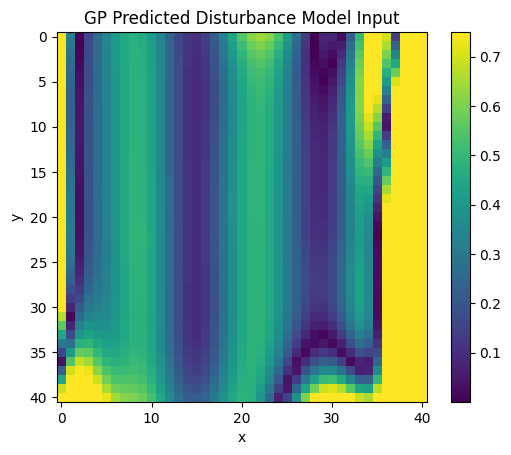

In [42]:
# Get learned value function from Partial GP Image 
device = "cpu" #"cuda:0"

num_std_away = 2.0
gp_flyaround_model_input, gp_predicted_disturbance_image_flyaround_add, gp_predicted_disturbance_image_flyaround_add_var = \
                                                gp_model_to_2dinput_image_with_clipping(flyaround_gp_model, grid_states, 
                                                                        vmin=0.0, 
                                                                        vmax=max_max_magnitude,
                                                                        num_std_away=num_std_away)

plt.figure()
plt.imshow(np.rot90(gp_flyaround_model_input, k=-1))
plt.colorbar()
plt.title("GP Predicted Disturbance Model Input")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

grid_states_torch = torch.from_numpy(grid_states).to(device).float()
grid_value_function_flyaround, channel_dim_flyaround, flattened_tensor_dataset_flyaround  = get_gridvalue_function_from_model(
    disturbance_input=torch.from_numpy(gp_flyaround_model_input[:, :, 0]).to(device).float(), 
    grid_states=np.array(grid_states), 
    model=model.to(device), 
    data_processor=data_processor, 
    device=device)

learned_value_function_flyaround = grid_value_function_flyaround

In [43]:
xvels = grid_states[0, 0, :, 0, 2]  # x velocities from grid states
yvels = grid_states[0, 0, 0, :, 3]  # y velocities from grid states
partial_xvels = np.array(ground_truth_hj_solution_flyaround.grid.states[0, 0, :, 0, 2])
partial_yvels = np.array(ground_truth_hj_solution_flyaround.grid.states[0, 0, 0, :, 3])

corresponding_indices = find_corresponding_indices(xvels, partial_xvels)
corresponding_indices_yvel = find_corresponding_indices(yvels, partial_yvels)
print("Corresponding indices: ", corresponding_indices)
print("num corsresponding indices: ", len(corresponding_indices))
print("\nCorresponding indices yvel: ", corresponding_indices_yvel)
print("num corsresponding indices yvel: ", len(corresponding_indices_yvel))

corresponding_indices_touse = [2, 5, 10, 15, 18]  #[0, 5, 10, 15, 20]  
corresponding_indices_touse_yvel = [10]
xvel_slices_partialcomp = [corresponding_indices[i][0] for i in corresponding_indices_touse]
partial_xvel_slices_partialcomp = [corresponding_indices[i][1] for i in corresponding_indices_touse]
yvel_slices_partialcomp = [corresponding_indices_yvel[i][0] for i in corresponding_indices_touse_yvel]
partial_yvel_slices_partialcomp = [corresponding_indices_yvel[i][1] for i in corresponding_indices_touse_yvel]

print("\nxvel slices: ", xvel_slices_partialcomp)
print("partial xvel slices: ", partial_xvel_slices_partialcomp)
print("\nxvels: ", xvels[xvel_slices_partialcomp])
print("partial xvels: ", partial_xvels[partial_xvel_slices_partialcomp])

print("\nyvel slices: ", yvel_slices_partialcomp)
print("partial yvel slices: ", partial_yvel_slices_partialcomp)
print("\nyvels: ", yvels[yvel_slices_partialcomp])
print("partial yvels: ", partial_yvels[partial_yvel_slices_partialcomp])


Corresponding indices:  [(0, 0), (2, 1), (4, 2), (6, 3), (8, 4), (10, 5), (12, 6), (14, 7), (16, 8), (18, 9), (20, 10), (22, 11), (24, 12), (26, 13), (28, 14), (30, 15), (32, 16), (34, 17), (36, 18), (38, 19), (40, 20)]
num corsresponding indices:  21

Corresponding indices yvel:  [(0, 0), (2, 1), (4, 2), (6, 3), (8, 4), (10, 5), (12, 6), (14, 7), (16, 8), (18, 9), (20, 10), (22, 11), (24, 12), (26, 13), (28, 14), (30, 15), (32, 16), (34, 17), (36, 18), (38, 19), (40, 20)]
num corsresponding indices yvel:  21

xvel slices:  [4, 10, 20, 30, 36]
partial xvel slices:  [2, 5, 10, 15, 18]

xvels:  [-1.5999999 -1.         0.         1.         1.6000001]
partial xvels:  [-1.5999999 -1.         0.         1.         1.6000001]

yvel slices:  [20]
partial yvel slices:  [10]

yvels:  [0.]
partial yvels:  [0.]


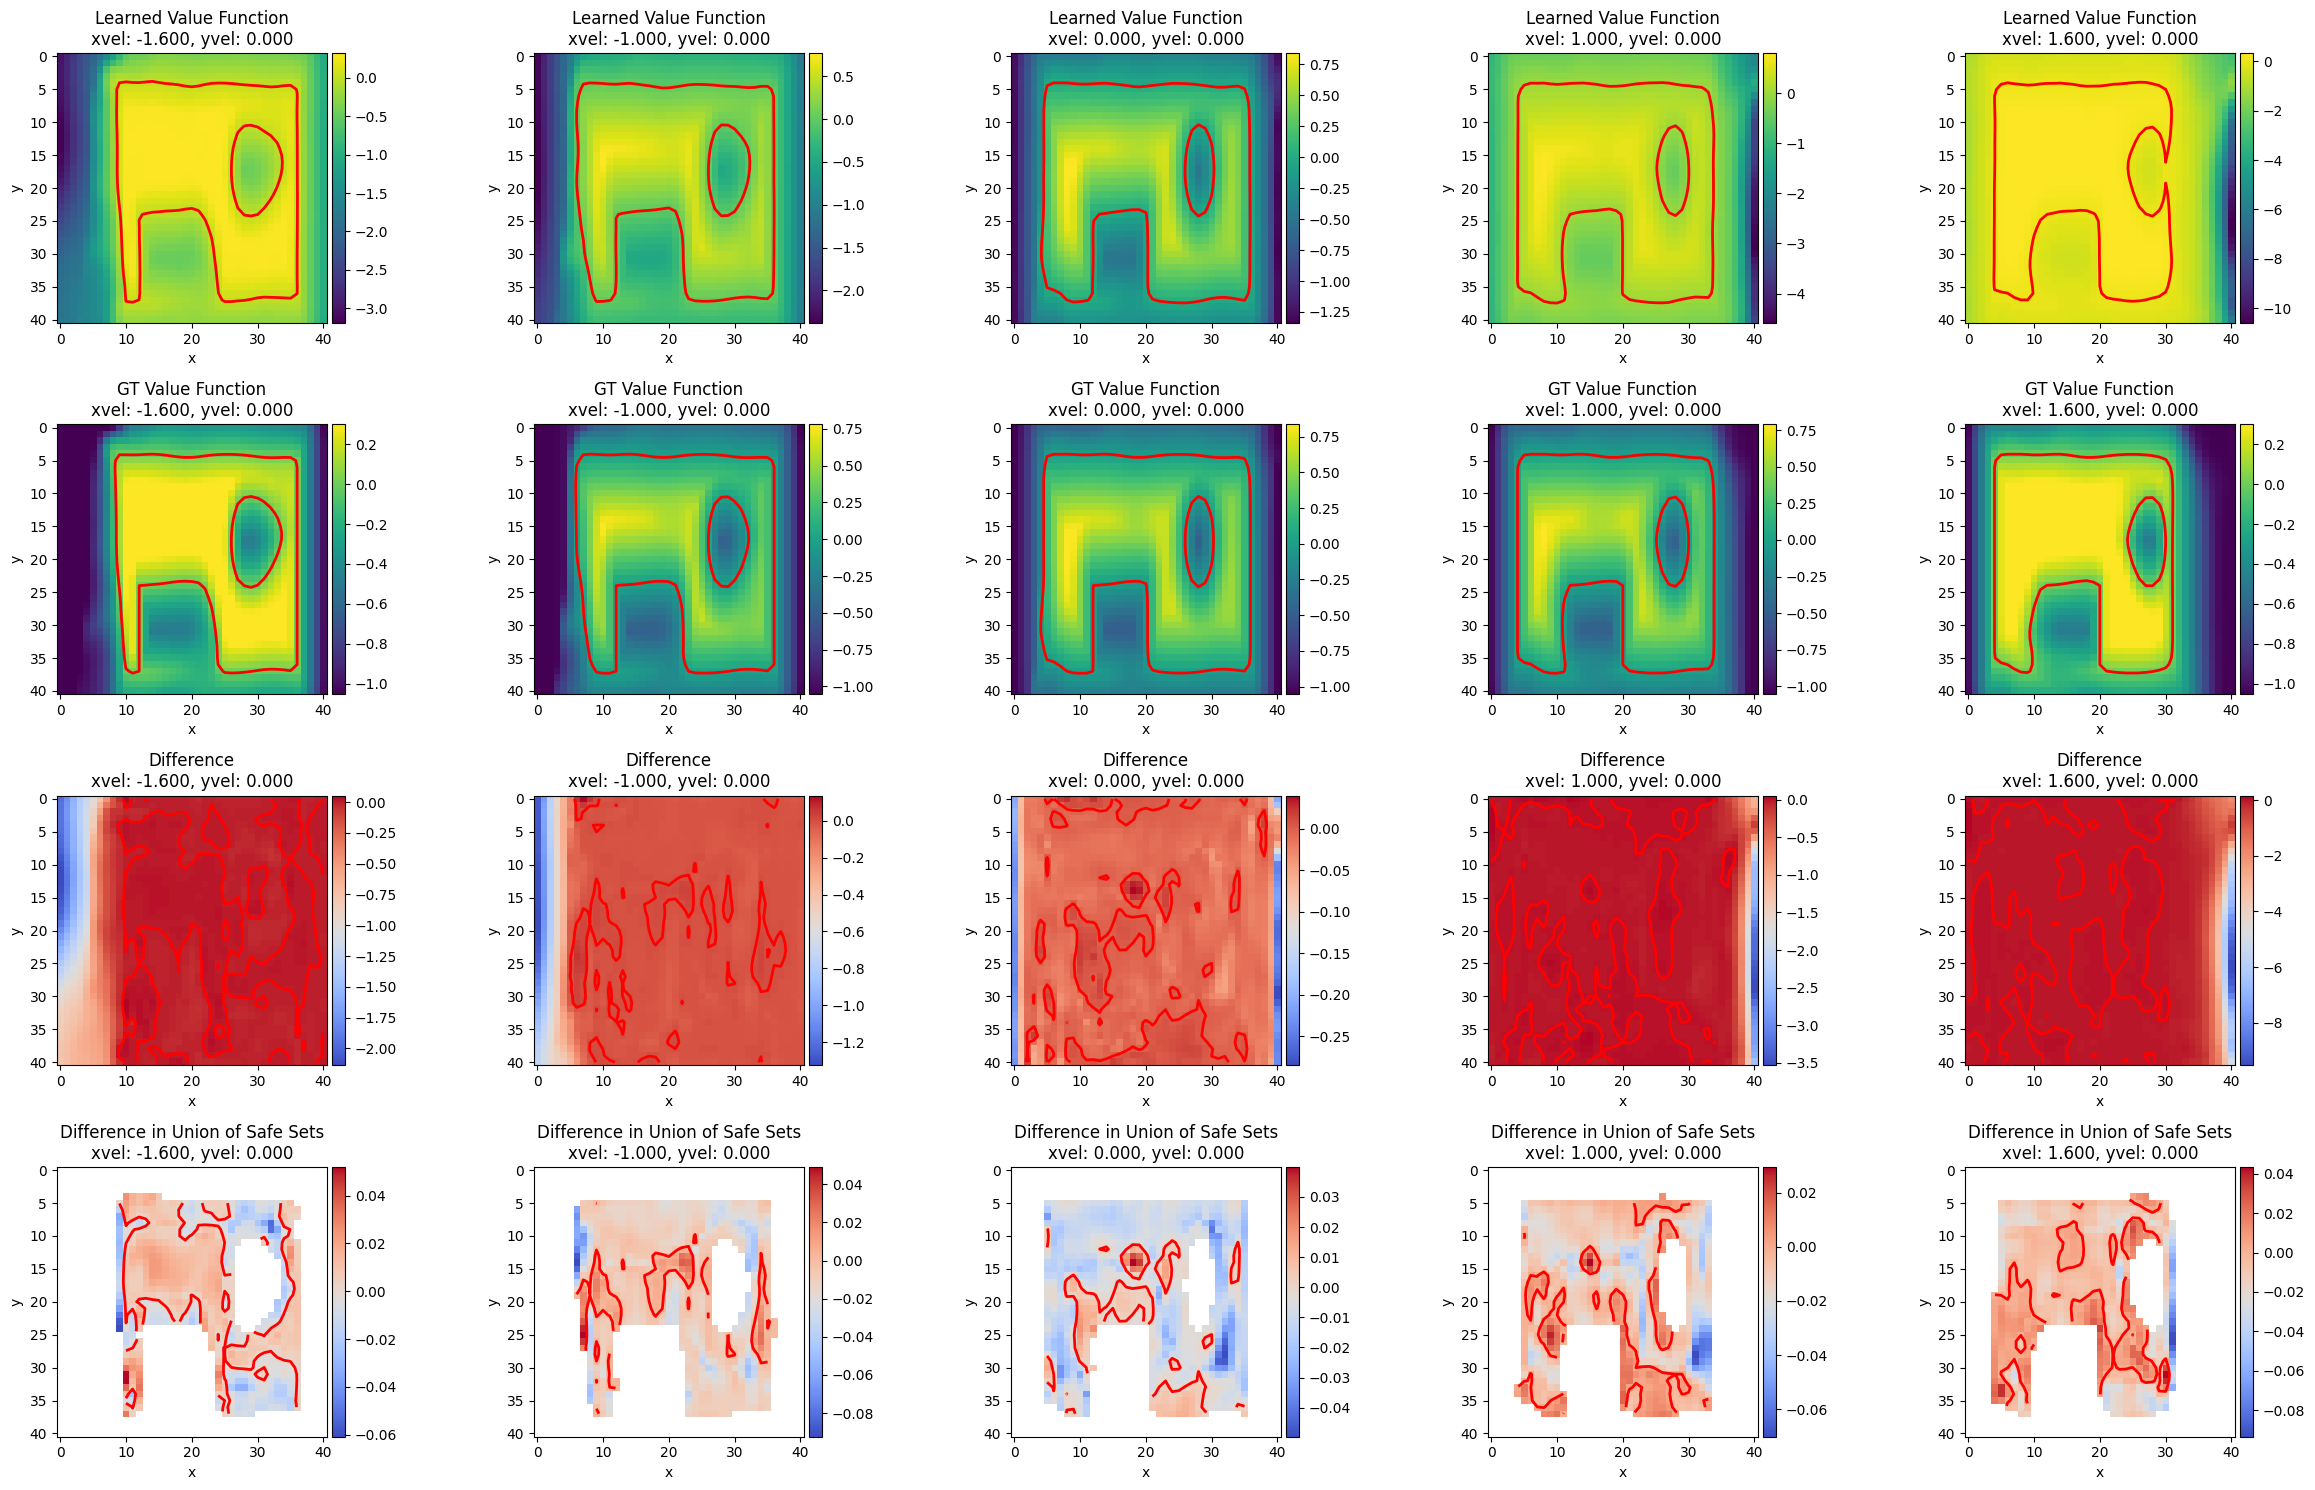

In [44]:
plot_value_functions_comparison_partial(learned_value_function=learned_value_function_flyaround, 
                                        gt_value_function=np.array(gt_value_function_flyaround), 
                                        xvels_testfn=xvels, 
                                        yvels_testfn=yvels, 
                                        xvels_gtfn=partial_xvels, 
                                        yvels_gtfn=partial_yvels, 
                                        xvel_slices_testfn=xvel_slices_partialcomp, yvel_slices_testfn=yvel_slices_partialcomp, 
                                        xvel_slices_gtfn=partial_xvel_slices_partialcomp, yvel_slices_gtfn=partial_yvel_slices_partialcomp)

## Full disturbance again

In [45]:
from safe_neural_operators.gp import GPWrapper

# Get Image from GP 
def gp_model_to_2dinput_image(gp_regression_model, grid_states): 
    """
    NOTE: not suitable for HJR and NN inputs, but useful for debugging GP and plotting with GP model

    Get the 2D disturbance input image from the GP model: 
    NOTE: GP model is only trained on [x,y] -> disturbance value: doesn't care about xvel, yvel here
    As a result image is disturbance value over the x,y grid only
    """
    # grid_states: [x, y, xvel, yvel, 4] state: [x,y,xvel,yvel]
    model_input_indices = [0, 1]  # x, y

    # Get states corresponding to image grid 
    image_grid = grid_states[:, :, 0, 0, :][:, :, model_input_indices]  # [x, y, 2]
    flattened_image_grid = image_grid.reshape(-1, image_grid.shape[-1])  # Flatten to [N, 2]

    # Get the corresponding outputs 
    flattened_disturbance_grid, flattened_disturbance_grid_var = gp_regression_model.predict(flattened_image_grid)  # [N, 2]

    # Reshape into same grid size 
    reconstructed_disturbance_grid = flattened_disturbance_grid.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]
    reconstructed_disturbance_grid_var = flattened_disturbance_grid_var.reshape(image_grid.shape[0], image_grid.shape[1], 1)  # [x, y, 1]   

    # Output as Image
    return reconstructed_disturbance_grid, reconstructed_disturbance_grid_var

In [46]:
# Load the data 

load_path = "/media/jingpei/DATA/fno_gp_data"
# load_path = "/media/jingpei/DATA/fno_data/fno_gp_data_full_partial_750"
use_full_partial_dataset = False

load_index = load_index = np.random.randint(0, 500) if randomize_index else 200 

loaded_input, loaded_output = load_hjr_solution(
    load_path=load_path,  
    load_index=load_index
)

if use_full_partial_dataset:
    grid_states = load_grid_states(load_path=load_path, load_index=0, load_prefix="full")
else:
    grid_states = load_grid_states(load_path=load_path, load_index=0)

print("loaded_input shape", loaded_input.shape)
print("loaded_output shape", loaded_output.shape)
print("grid_states shape", grid_states.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/media/jingpei/DATA/fno_gp_data/290_input.pt'

In [ ]:
# Grid states to input image using GP function
image_grid = grid_states[:, :, 0, 0, :]
disturbance_grid = loaded_input

print("Image grid: ", image_grid.shape)
print("Disturbance grid: ", disturbance_grid.shape)

flattened_image_grid = image_grid.reshape(-1, image_grid.shape[-1])
flattened_disturbance_grid = disturbance_grid.reshape(-1, disturbance_grid.shape[-1])
reconstructed_image_grid = flattened_image_grid.reshape(image_grid.shape)
reconstructed_disturbance_grid = flattened_disturbance_grid.reshape(disturbance_grid.shape) 

Image grid:  (41, 41, 4)
Disturbance grid:  torch.Size([41, 41, 4])


In [ ]:
# Create and train GP Model 
num_init_indices = 1000
random_indices = np.random.choice(flattened_image_grid.shape[0], size=num_init_indices, replace=False)

model_input_indices = [0, 1] # x,y
x_init = flattened_image_grid[random_indices, :][:, model_input_indices]
y_init = flattened_disturbance_grid[random_indices, :][:, 0:1] # Have the disturbance magnitude be one number only
print("x_init shape: ", x_init.shape)
print("y_init shape: ", y_init.shape)

gp_model = GPWrapper(X_init=x_init, Y_init=y_init, optimize=True)
print(gp_model.model)

x_init shape:  (1000, 2)
y_init shape:  torch.Size([1000, 1])

Name : GP regression
Objective : -4985.727447081059
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                   value  |  constraints  |  priors
  rbf.variance             |     0.03776363881541998  |      +ve      |        
  rbf.lengthscale          |      0.4021639567694939  |      +ve      |        
  Gaussian_noise.variance  |  5.4360215450213125e-16  |      +ve      |        


In [ ]:
gp_predicted_disturbance_image, gp_predicted_disturbance_var_image  = gp_model_to_2dinput_image(gp_model, grid_states)

GP predicted disturbance image shape:  (41, 41, 1)
Original disturbance grid shape:  torch.Size([41, 41, 4])
Difference shape:  torch.Size([41, 41])


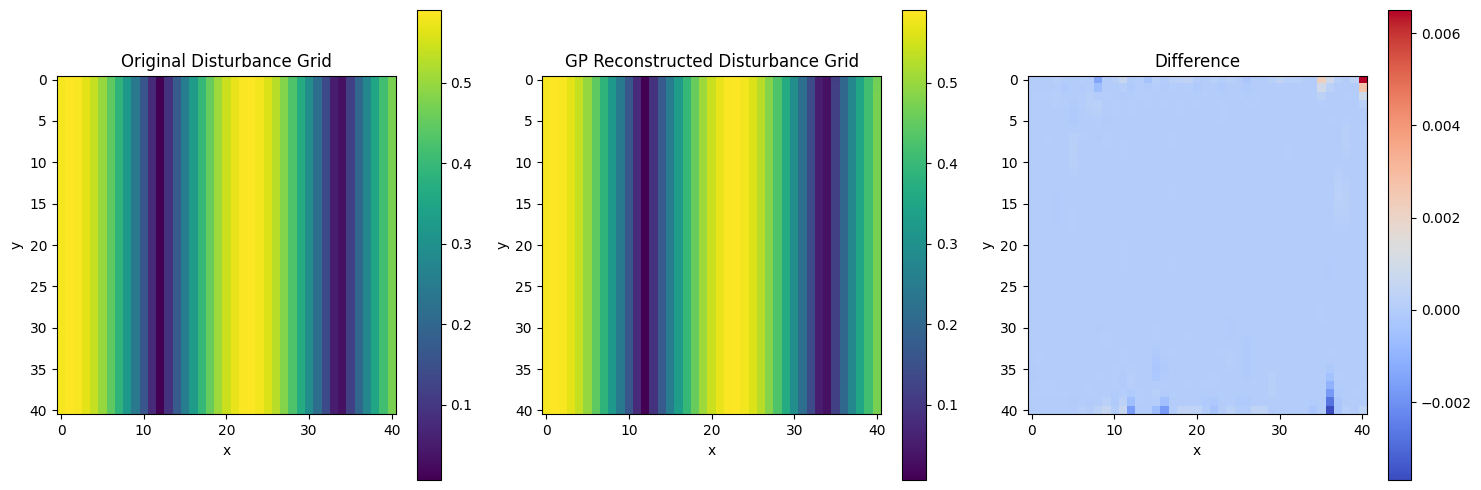

In [ ]:
gp_predicted_disturbance_image, gp_predicted_disturbance_var_image  = gp_model_to_2dinput_image(gp_model, grid_states)

# Calculate the difference
difference = disturbance_grid[:, :, 0] - gp_predicted_disturbance_image[:, :, 0]
print("GP predicted disturbance image shape: ", gp_predicted_disturbance_image.shape)
print("Original disturbance grid shape: ", disturbance_grid.shape)
print("Difference shape: ", difference.shape)

# Plot the original disturbance grid, GP reconstructed one, and the difference
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.rot90(disturbance_grid[:, :, 0]), cmap='viridis', interpolation='nearest')
axes[0].set_title("Original Disturbance Grid")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
im0 = axes[0].imshow(np.rot90(disturbance_grid[:, :, 0]), cmap='viridis', interpolation='nearest')
fig.colorbar(im0, ax=axes[0])

axes[1].imshow(np.rot90(np.rot90(gp_predicted_disturbance_image[:, :, 0])), cmap='viridis', interpolation='nearest')
axes[1].set_title("GP Reconstructed Disturbance Grid")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
im1 = axes[1].imshow(np.rot90(gp_predicted_disturbance_image[:, :, 0]), cmap='viridis', interpolation='nearest')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.rot90(difference), cmap='coolwarm', interpolation='nearest')
axes[2].set_title("Difference")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [ ]:
# Get the Value Function from GP Model
device = "cpu" #"cuda:0"


grid_states_torch = torch.from_numpy(grid_states).to(device).float()
grid_value_function, channel_dim, flattened_tensor_dataset  = get_gridvalue_function_from_model(
    disturbance_input=torch.from_numpy(gp_predicted_disturbance_image[:, :, 0]).to(device).float(), 
    grid_states=np.array(grid_states), 
    model=model.to(device), 
    data_processor=data_processor, 
    device=device)

learned_value_function = grid_value_function


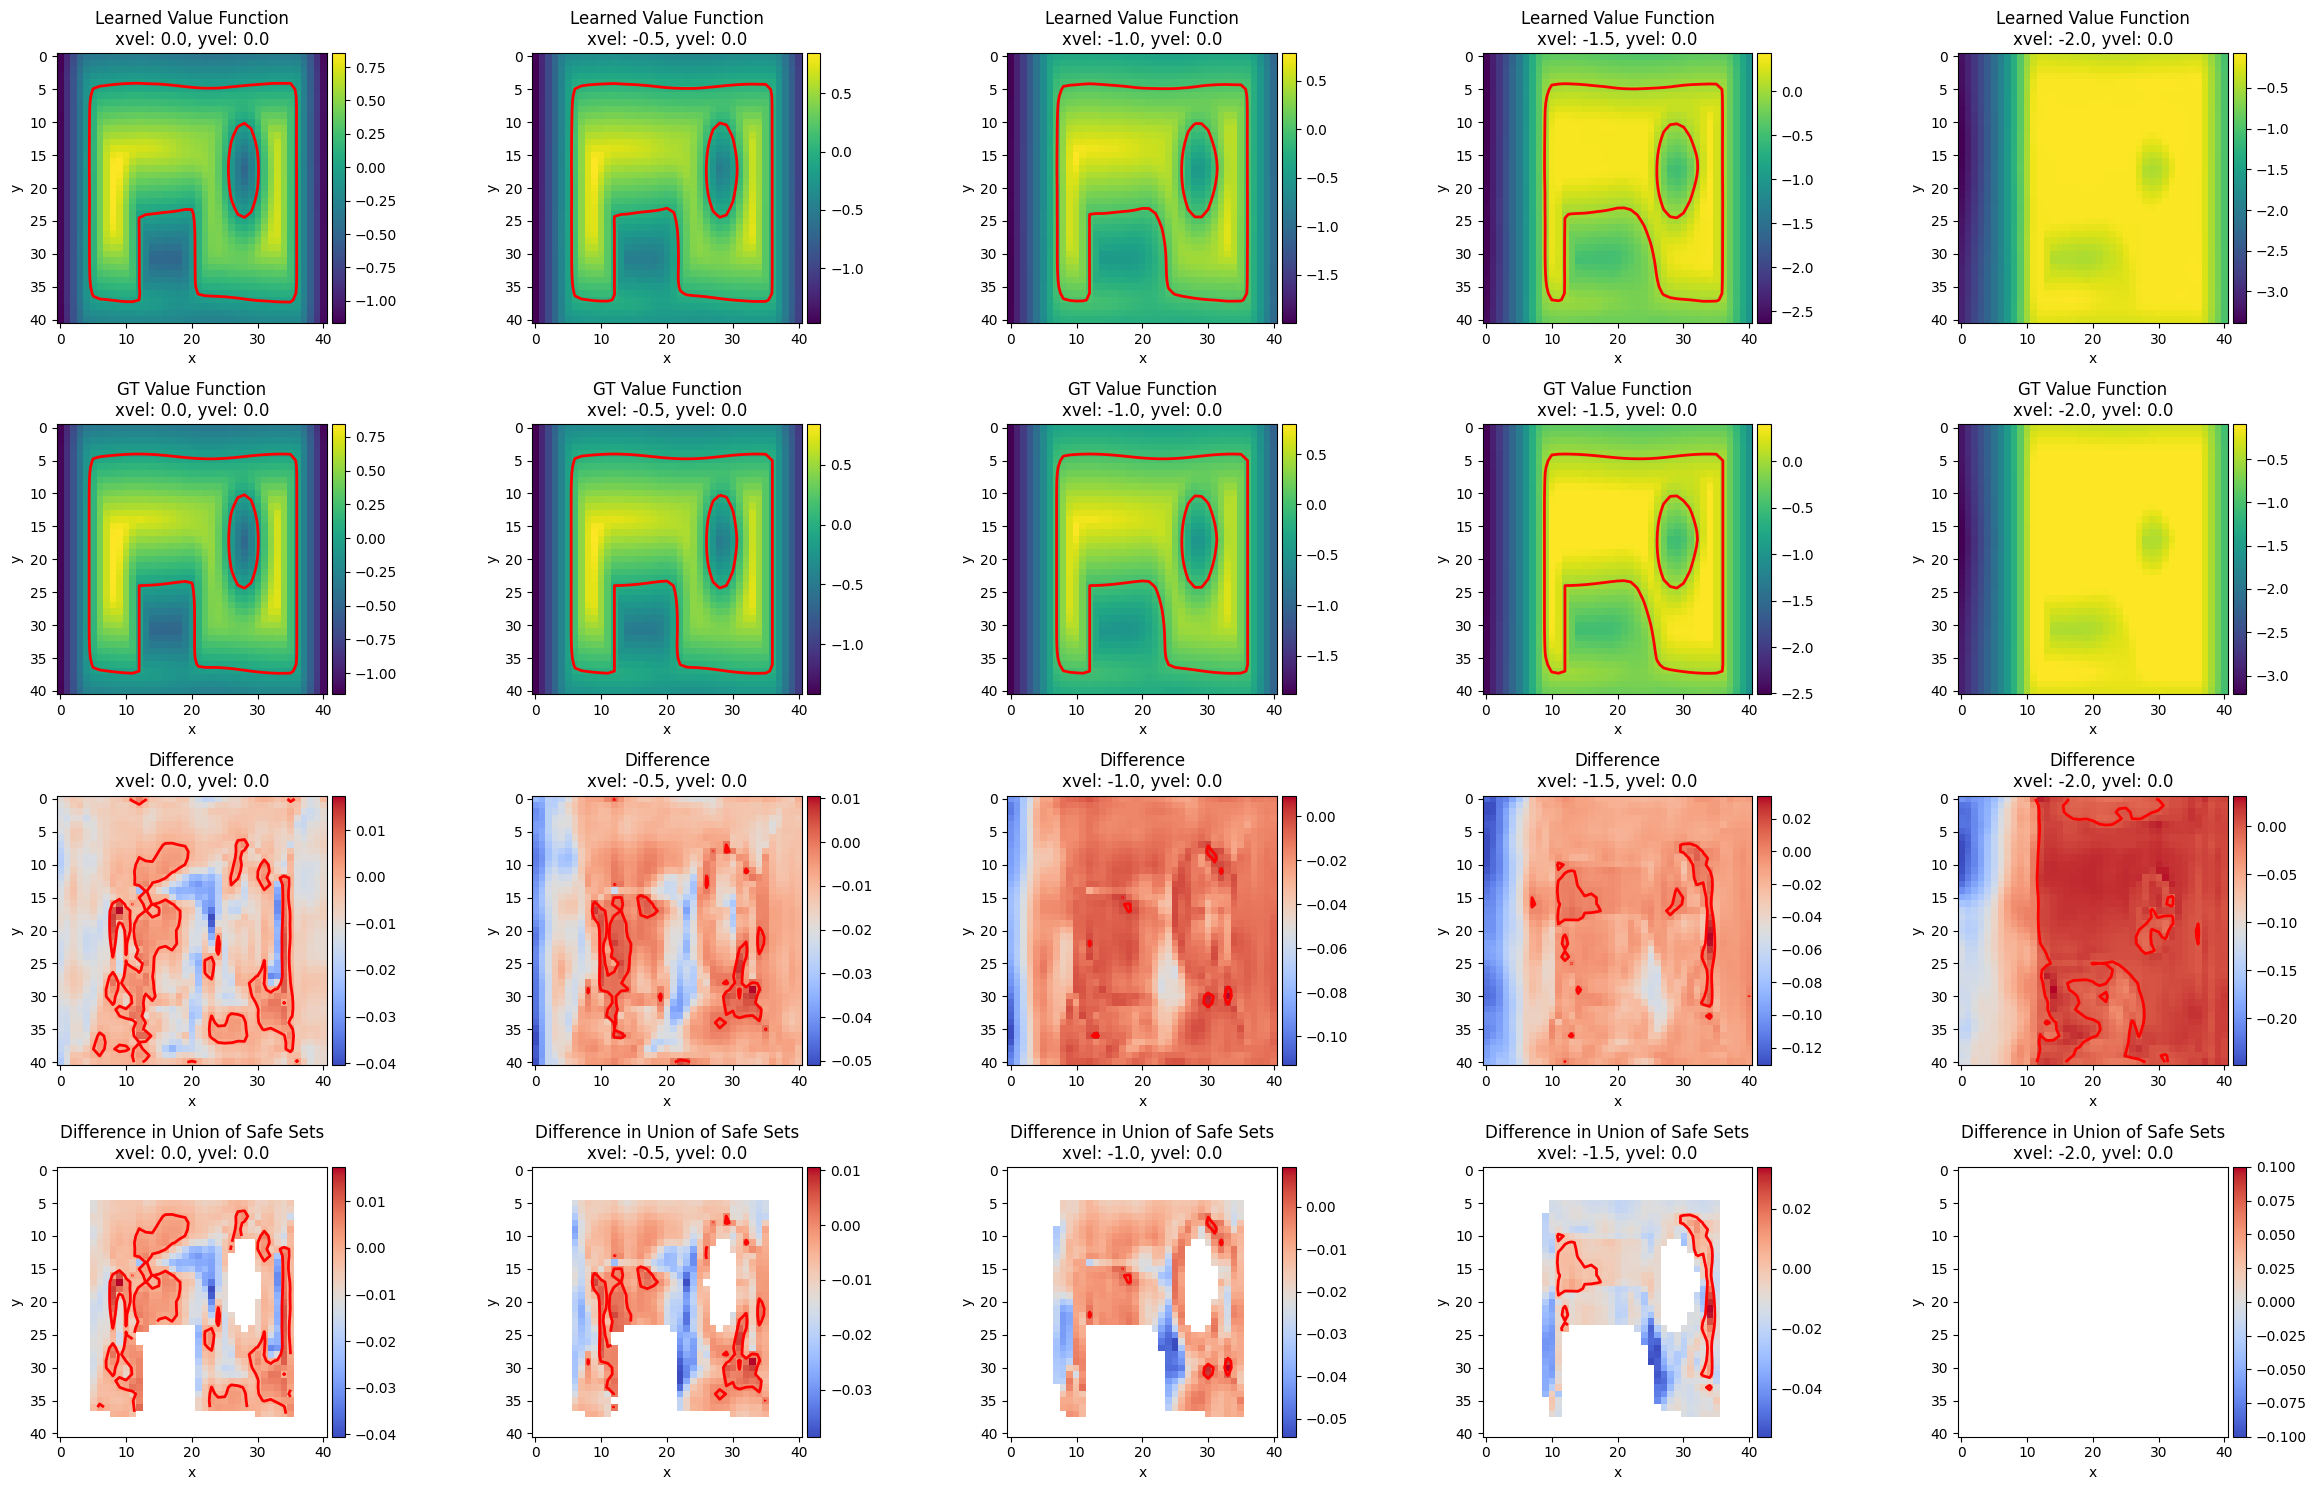

In [ ]:
plot_value_functions_comparison(learned_value_function, gt_value_function=loaded_output, xvels=xvels, yvels=yvels, xvel_slices = [20, 15, 10, 5, 0], yvel_slices=[20])

# DEBUGGING BELOW